# NumPy XP Ninja Exercises - Week 5 Day 2


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy import stats
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Scikit-learn available for StandardScaler")

Libraries imported successfully!
NumPy version: 2.3.3
Matplotlib version: 3.10.7
Seaborn version: 0.13.2
Scikit-learn available for StandardScaler


## Exercise 1: Diagonal Matrix Operations

**Challenge**: Extract diagonal elements from a 4x4 matrix and create a diagonal matrix.

**Concepts**: 
- Diagonal extraction using `np.diag()`
- Diagonal matrix construction
- Matrix properties and operations

Exercise 1 - Diagonal Matrix Operations:
Creating 4x4 matrix and extracting diagonal elements
------------------------------------------------------------
Original 4x4 Matrix:
[[ 7 15 11  8]
 [ 7 19 11 11]
 [ 4  8  3  2]
 [12  6  2  1]]
Matrix shape: (4, 4)
Matrix dtype: int32

Extracted Diagonal Elements:
Diagonal: [ 7 19  3  1]
Diagonal length: 4

Diagonal Matrix created from extracted elements:
[[ 7  0  0  0]
 [ 0 19  0  0]
 [ 0  0  3  0]
 [ 0  0  0  1]]

Verification - Is it a diagonal matrix? True

Advanced Diagonal Operations:
----------------------------------------
Super-diagonal (k=1): [15 11  2]
Sub-diagonal (k=-1): [7 8 2]

Custom diagonal matrix [10, 20, 30, 40]:
[[10  0  0  0]
 [ 0 20  0  0]
 [ 0  0 30  0]
 [ 0  0  0 40]]

Trace of original matrix: 30
Trace of diagonal matrix: 30
Are traces equal? True

Diagonal Matrix Properties:
-----------------------------------
Determinant of diagonal matrix: 399.00
Product of diagonal elements: 399.00
Are they equal? True

Inverse of

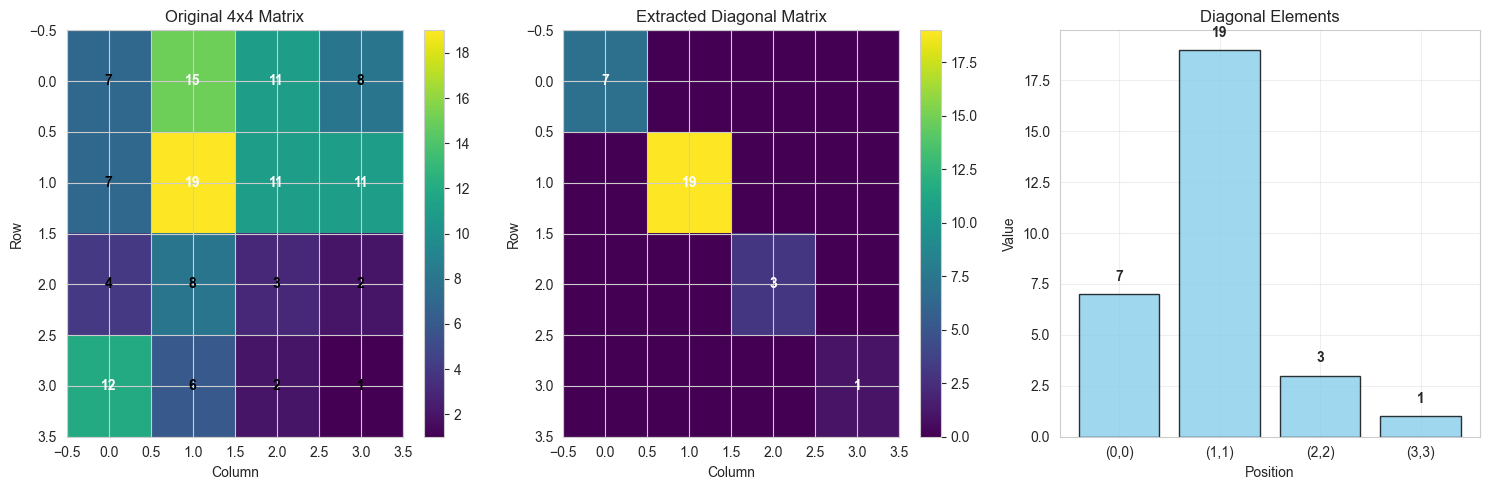


Mathematical Representation:
-----------------------------------
Diagonal Matrix D =
⎡  7   0   0   0⎤
⎢  0  19   0   0⎥
⎢  0   0   3   0⎥
⎣  0   0   0   1⎦

Key Properties of Diagonal Matrices:
• Only diagonal elements are non-zero
• Determinant = product of diagonal elements
• Eigenvalues = diagonal elements
• Easy to compute powers: D^n has diagonal elements raised to power n
• Inverse exists if no diagonal element is zero
• Multiplication is commutative with other diagonal matrices


In [9]:
print("Exercise 1 - Diagonal Matrix Operations:")
print("Creating 4x4 matrix and extracting diagonal elements")
print("-" * 60)

# 4x4 matrix with random values
np.random.seed(42)
matrix_4x4 = np.random.randint(1, 20, size=(4, 4))

print("Original 4x4 Matrix:")
print(matrix_4x4)
print(f"Matrix shape: {matrix_4x4.shape}")
print(f"Matrix dtype: {matrix_4x4.dtype}")

# Extract diagonal elements using np.diag()
diagonal_elements = np.diag(matrix_4x4)
print(f"\nExtracted Diagonal Elements:")
print(f"Diagonal: {diagonal_elements}")
print(f"Diagonal length: {len(diagonal_elements)}")

# Create diagonal matrix from these elements
diagonal_matrix = np.diag(diagonal_elements)
print(f"\nDiagonal Matrix created from extracted elements:")
print(diagonal_matrix)

# Verify it's truly diagonal (all non-diagonal elements are 0)
is_diagonal = np.allclose(diagonal_matrix, np.diag(np.diag(diagonal_matrix)))
print(f"\nVerification - Is it a diagonal matrix? {is_diagonal}")

# Advanced diagonal operations
print(f"\nAdvanced Diagonal Operations:")
print("-" * 40)

# Extract super-diagonal (one above main diagonal)
super_diagonal = np.diag(matrix_4x4, k=1)
print(f"Super-diagonal (k=1): {super_diagonal}")

# Extract sub-diagonal (one below main diagonal) 
sub_diagonal = np.diag(matrix_4x4, k=-1)
print(f"Sub-diagonal (k=-1): {sub_diagonal}")

# Create diagonal matrix with different values
custom_diagonal = np.diag([10, 20, 30, 40])
print(f"\nCustom diagonal matrix [10, 20, 30, 40]:")
print(custom_diagonal)

# Trace (sum of diagonal elements)
trace_original = np.trace(matrix_4x4)
trace_diagonal = np.trace(diagonal_matrix)
print(f"\nTrace of original matrix: {trace_original}")
print(f"Trace of diagonal matrix: {trace_diagonal}")
print(f"Are traces equal? {trace_original == trace_diagonal}")

# Diagonal operations and properties
print(f"\nDiagonal Matrix Properties:")
print("-" * 35)

# Determinant of diagonal matrix (product of diagonal elements)
det_diagonal = np.linalg.det(diagonal_matrix)
product_diagonal = np.prod(diagonal_elements)
print(f"Determinant of diagonal matrix: {det_diagonal:.2f}")
print(f"Product of diagonal elements: {product_diagonal:.2f}")
print(f"Are they equal? {np.isclose(det_diagonal, product_diagonal)}")

# Inverse of diagonal matrix
if not np.any(diagonal_elements == 0):
    inverse_diagonal = np.linalg.inv(diagonal_matrix)
    manual_inverse = np.diag(1.0 / diagonal_elements)
    print(f"\nInverse of diagonal matrix:")
    print(inverse_diagonal)
    print(f"Manual inverse (1/diagonal elements):")
    print(manual_inverse)
    print(f"Are inverses equal? {np.allclose(inverse_diagonal, manual_inverse)}")
else:
    print(f"\nCannot compute inverse - matrix contains zero on diagonal")

# Eigenvalues of diagonal matrix
eigenvalues = np.linalg.eigvals(diagonal_matrix)
print(f"\nEigenvalues of diagonal matrix: {eigenvalues}")
print(f"Diagonal elements: {diagonal_elements}")
print(f"Eigenvalues = Diagonal elements? {np.allclose(sorted(eigenvalues), sorted(diagonal_elements))}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original matrix
im1 = axes[0].imshow(matrix_4x4, cmap='viridis', aspect='auto')
axes[0].set_title('Original 4x4 Matrix')
axes[0].set_xlabel('Column')
axes[0].set_ylabel('Row')
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, str(matrix_4x4[i, j]), ha='center', va='center', 
                    color='white' if matrix_4x4[i, j] > 10 else 'black', fontweight='bold')
plt.colorbar(im1, ax=axes[0])

# Diagonal matrix
im2 = axes[1].imshow(diagonal_matrix, cmap='viridis', aspect='auto')
axes[1].set_title('Extracted Diagonal Matrix')
axes[1].set_xlabel('Column')
axes[1].set_ylabel('Row')
for i in range(4):
    for j in range(4):
        if diagonal_matrix[i, j] != 0:
            axes[1].text(j, i, str(int(diagonal_matrix[i, j])), ha='center', va='center', 
                        color='white', fontweight='bold')
plt.colorbar(im2, ax=axes[1])

# Comparison plot
axes[2].bar(range(4), diagonal_elements, color='skyblue', alpha=0.8, edgecolor='black')
axes[2].set_title('Diagonal Elements')
axes[2].set_xlabel('Position')
axes[2].set_ylabel('Value')
axes[2].set_xticks(range(4))
axes[2].set_xticklabels([f'({i},{i})' for i in range(4)])
for i, val in enumerate(diagonal_elements):
    axes[2].text(i, val + 0.5, str(val), ha='center', va='bottom', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mathematical representation
print(f"\nMathematical Representation:")
print("-" * 35)
print("Diagonal Matrix D =")
print("⎡{:3} {:3} {:3} {:3}⎤".format(diagonal_elements[0], 0, 0, 0))
print("⎢{:3} {:3} {:3} {:3}⎥".format(0, diagonal_elements[1], 0, 0))
print("⎢{:3} {:3} {:3} {:3}⎥".format(0, 0, diagonal_elements[2], 0))
print("⎣{:3} {:3} {:3} {:3}⎦".format(0, 0, 0, diagonal_elements[3]))

print(f"\nKey Properties of Diagonal Matrices:")
print("• Only diagonal elements are non-zero")
print("• Determinant = product of diagonal elements")
print("• Eigenvalues = diagonal elements") 
print("• Easy to compute powers: D^n has diagonal elements raised to power n")
print("• Inverse exists if no diagonal element is zero")
print("• Multiplication is commutative with other diagonal matrices")

## Exercise 2: Conditional Array Operations

**Challenge**: Generate a 1D array with 20 random elements and replace values > 0.5 with -1.


Exercise 2 - Conditional Array Operations:
Advanced boolean indexing and conditional replacements
------------------------------------------------------------
Original Array (20 random elements):
Array: [0.54340494 0.27836939 0.42451759 0.84477613 0.00471886 0.12156912
 0.67074908 0.82585276 0.13670659 0.57509333 0.89132195 0.20920212
 0.18532822 0.10837689 0.21969749 0.97862378 0.81168315 0.17194101
 0.81622475 0.27407375]
Array shape: (20,)
Array dtype: float64
Min value: 0.005
Max value: 0.979

Elements > 0.5: 9 out of 20
Indices of elements > 0.5: [ 0  3  6  7  9 10 15 16 18]

Method 1 - Direct Boolean Indexing:
Modified array: [-1.          0.27836939  0.42451759 -1.          0.00471886  0.12156912
 -1.         -1.          0.13670659 -1.         -1.          0.20920212
  0.18532822  0.10837689  0.21969749 -1.         -1.          0.17194101
 -1.          0.27407375]

Method 2 - Using np.where:
Modified array: [-1.          0.27836939  0.42451759 -1.          0.00471886  0.1215691

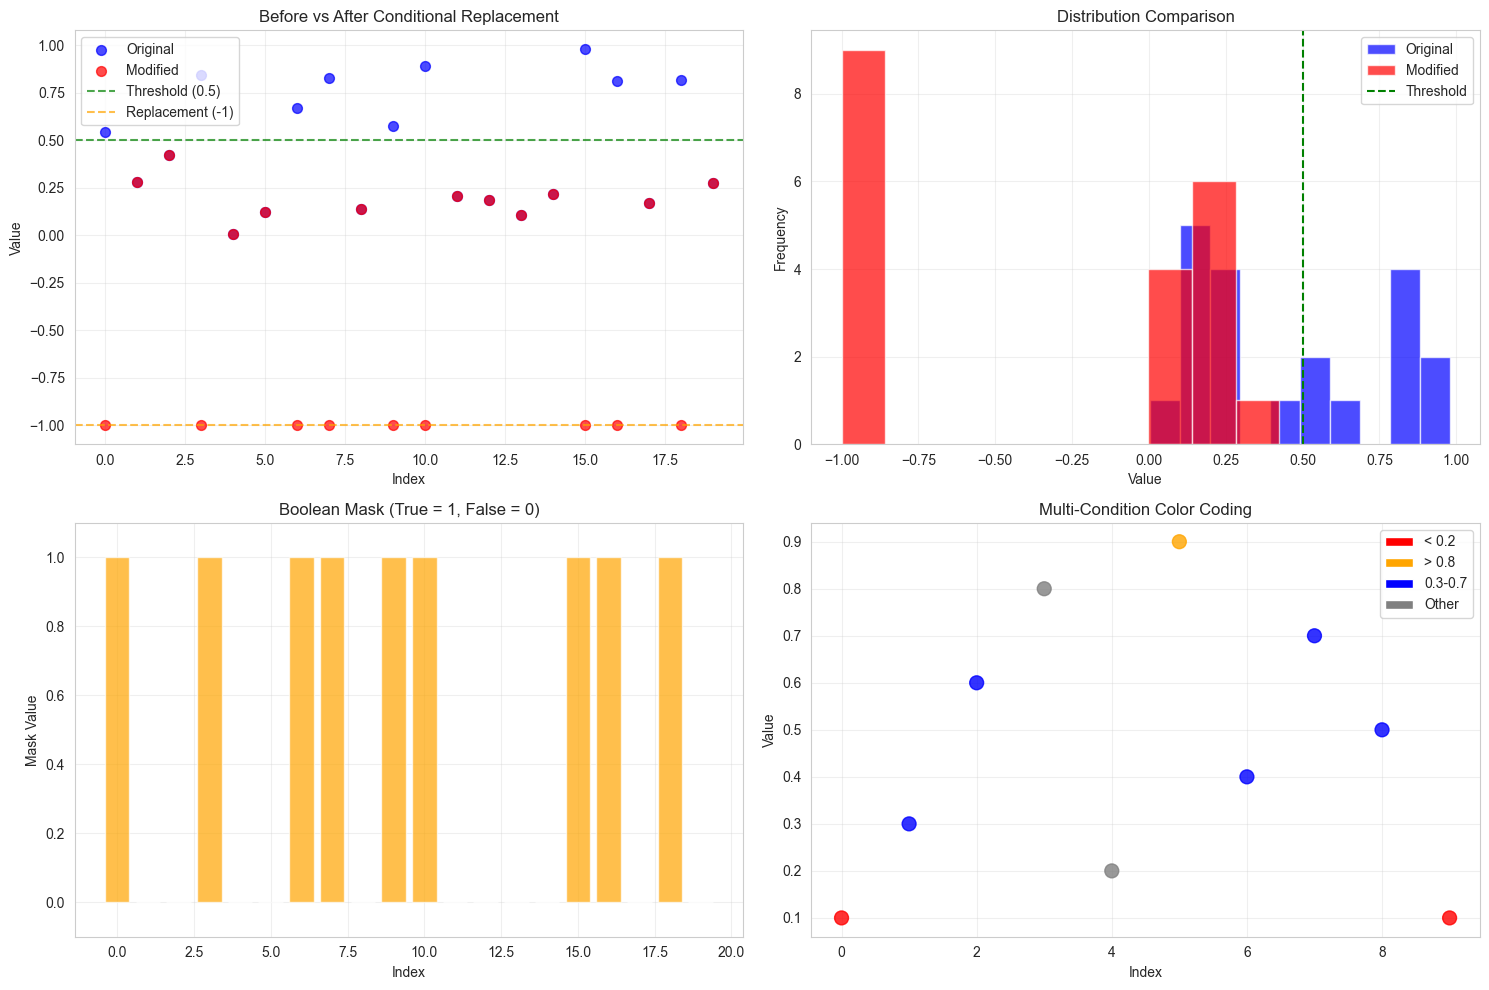


Performance Insights:
-------------------------
• Boolean indexing is generally fastest for simple conditions
• np.where is more readable for complex conditional logic
• np.select is best for multiple conditions with different outcomes
• np.clip is efficient for range limiting operations

Conditional Operations Summary:
• Boolean masks create True/False arrays for filtering
• Direct indexing with masks enables in-place modifications
• Compound conditions use & (and), | (or), ~ (not) operators
• np.where, np.select, and np.clip provide different conditional paradigms
• Modified 9 elements from original array


In [10]:
print("Exercise 2 - Conditional Array Operations:")
print("Advanced boolean indexing and conditional replacements")
print("-" * 60)

# 1D array with 20 random elements (0 to 1)
np.random.seed(100)
random_array = np.random.random(20)

print("Original Array (20 random elements):")
print(f"Array: {random_array}")
print(f"Array shape: {random_array.shape}")
print(f"Array dtype: {random_array.dtype}")
print(f"Min value: {random_array.min():.3f}")
print(f"Max value: {random_array.max():.3f}")

# Count elements > 0.5 before replacement
mask_greater_05 = random_array > 0.5
count_greater = np.sum(mask_greater_05)
print(f"\nElements > 0.5: {count_greater} out of {len(random_array)}")
print(f"Indices of elements > 0.5: {np.where(mask_greater_05)[0]}")

# Method 1: Direct boolean indexing replacement
array_method1 = random_array.copy()
array_method1[array_method1 > 0.5] = -1

print(f"\nMethod 1 - Direct Boolean Indexing:")
print(f"Modified array: {array_method1}")

# Method 2: Using np.where for conditional replacement
array_method2 = np.where(random_array > 0.5, -1, random_array)

print(f"\nMethod 2 - Using np.where:")
print(f"Modified array: {array_method2}")

# Method 3: Using np.select for multiple conditions
conditions = [random_array > 0.5, random_array <= 0.5]
choices = [-1, random_array]
array_method3 = np.select(conditions, choices)

print(f"\nMethod 3 - Using np.select:")
print(f"Modified array: {array_method3}")

# Verify all methods give same result
methods_equal = np.array_equal(array_method1, array_method2) and np.array_equal(array_method2, array_method3)
print(f"\nAll methods produce identical results: {methods_equal}")

# Advanced conditional operations
print(f"\nAdvanced Conditional Operations:")
print("-" * 40)

# Complex conditions with multiple criteria
complex_array = np.random.randn(15) * 2 + 1

print(f"Original complex array: {complex_array}")

# Multiple condition replacements
conditions_advanced = [
    (complex_array < -1),           # Very negative -> 0
    (complex_array >= -1) & (complex_array < 0),  # Slightly negative -> 0.5
    (complex_array >= 0) & (complex_array < 2),   # Positive moderate -> keep
    (complex_array >= 2)            # Very positive -> 10
]

choices_advanced = [0, 0.5, complex_array, 10]
result_advanced = np.select(conditions_advanced, choices_advanced)

print(f"Multi-condition result: {result_advanced}")

# Statistics before and after
print(f"\nStatistical Analysis:")
print("-" * 25)

original_stats = {
    'Mean': np.mean(random_array),
    'Std': np.std(random_array),
    'Min': np.min(random_array),
    'Max': np.max(random_array),
    'Count > 0.5': np.sum(random_array > 0.5)
}

modified_stats = {
    'Mean': np.mean(array_method1),
    'Std': np.std(array_method1),
    'Min': np.min(array_method1),
    'Max': np.max(array_method1),
    'Count = -1': np.sum(array_method1 == -1)
}

print("Original Array Statistics:")
for key, value in original_stats.items():
    print(f"  {key}: {value:.3f}")

print("\nModified Array Statistics:")
for key, value in modified_stats.items():
    print(f"  {key}: {value:.3f}")

# Boolean operations
print(f"\nAdvanced Boolean Operations:")
print("-" * 35)

# Test array for advanced operations
test_array = np.array([0.1, 0.3, 0.6, 0.8, 0.2, 0.9, 0.4, 0.7, 0.5, 0.1])
print(f"Test array: {test_array}")

# Multiple boolean operations
between_03_07 = (test_array >= 0.3) & (test_array <= 0.7)
outside_02_08 = (test_array < 0.2) | (test_array > 0.8)
exactly_05 = test_array == 0.5

print(f"Elements between 0.3 and 0.7: {test_array[between_03_07]}")
print(f"Elements outside 0.2-0.8 range: {test_array[outside_02_08]}")
print(f"Elements exactly 0.5: {test_array[exactly_05]}")

# Using np.clip for range limiting
clipped_array = np.clip(test_array, 0.2, 0.8)
print(f"Clipped to [0.2, 0.8]: {clipped_array}")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Before and after comparison
x_indices = np.arange(len(random_array))
axes[0, 0].scatter(x_indices, random_array, color='blue', alpha=0.7, label='Original', s=50)
axes[0, 0].scatter(x_indices, array_method1, color='red', alpha=0.7, label='Modified', s=50)
axes[0, 0].axhline(y=0.5, color='green', linestyle='--', alpha=0.7, label='Threshold (0.5)')
axes[0, 0].axhline(y=-1, color='orange', linestyle='--', alpha=0.7, label='Replacement (-1)')
axes[0, 0].set_title('Before vs After Conditional Replacement')
axes[0, 0].set_xlabel('Index')
axes[0, 0].set_ylabel('Value')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Histogram comparison
axes[0, 1].hist(random_array, bins=10, alpha=0.7, color='blue', label='Original')
axes[0, 1].hist(array_method1, bins=10, alpha=0.7, color='red', label='Modified')
axes[0, 1].axvline(x=0.5, color='green', linestyle='--', label='Threshold')
axes[0, 1].set_title('Distribution Comparison')
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Boolean mask visualization
axes[1, 0].bar(x_indices, mask_greater_05.astype(int), color='orange', alpha=0.7)
axes[1, 0].set_title('Boolean Mask (True = 1, False = 0)')
axes[1, 0].set_xlabel('Index')
axes[1, 0].set_ylabel('Mask Value')
axes[1, 0].set_ylim(-0.1, 1.1)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Advanced conditions visualization
x_test = np.arange(len(test_array))
colors = ['red' if val < 0.2 else 'orange' if val > 0.8 else 'blue' if 0.3 <= val <= 0.7 else 'gray' 
          for val in test_array]
axes[1, 1].scatter(x_test, test_array, c=colors, s=100, alpha=0.8)
axes[1, 1].set_title('Multi-Condition Color Coding')
axes[1, 1].set_xlabel('Index')
axes[1, 1].set_ylabel('Value')
axes[1, 1].grid(True, alpha=0.3)

# Legend for colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='red', label='< 0.2'),
                  Patch(facecolor='orange', label='> 0.8'),
                  Patch(facecolor='blue', label='0.3-0.7'),
                  Patch(facecolor='gray', label='Other')]
axes[1, 1].legend(handles=legend_elements)

plt.tight_layout()
plt.show()

# Performance comparison of methods
print(f"\nPerformance Insights:")
print("-" * 25)
print("• Boolean indexing is generally fastest for simple conditions")
print("• np.where is more readable for complex conditional logic")
print("• np.select is best for multiple conditions with different outcomes")
print("• np.clip is efficient for range limiting operations")

print(f"\nConditional Operations Summary:")
print("• Boolean masks create True/False arrays for filtering")
print("• Direct indexing with masks enables in-place modifications")
print("• Compound conditions use & (and), | (or), ~ (not) operators")
print("• np.where, np.select, and np.clip provide different conditional paradigms")
print(f"• Modified {count_greater} elements from original array")

## Exercise 3: Data Normalization

**Challenge**: Normalize a 1D array using the formula: $x_{normalized} = \frac{x - \mu}{\sigma}$


Exercise 3 - Data Normalization:
Implementing Z-score normalization: (x - μ) / σ
-------------------------------------------------------
Original Data:
Data: [46.52925129 55.85919842 55.37446201 58.49366718 52.49350987 78.7011819
 54.54354117 37.53760534 49.09786506 48.58558796 29.48382828 41.1122287
 44.41301406 75.91650636 90.39289064 29.36195891 79.3597355  28.0045884
 47.97586484 20.75414824 57.83561413 31.08301327 48.89960299 17.88595289
 39.00197192 24.27822592 70.55344482 49.99124968  9.88628794 61.9145057 ]
Data shape: (30,)
Data type: float64

Original Data Statistics:
Mean (μ): 47.8440
Standard Deviation (σ - population): 19.0526
Standard Deviation (σ - sample): 19.3783
Minimum: 9.8863
Maximum: 90.3929
Range: 80.5066

Method 1 - Manual Z-score Normalization:
Formula: x_normalized = (x - μ) / σ
---------------------------------------------
Normalized data: [-0.06900711  0.42068682  0.39524483  0.55896021  0.24403446  1.61957687
  0.35163291 -0.54094488  0.06580979  0.03892229 

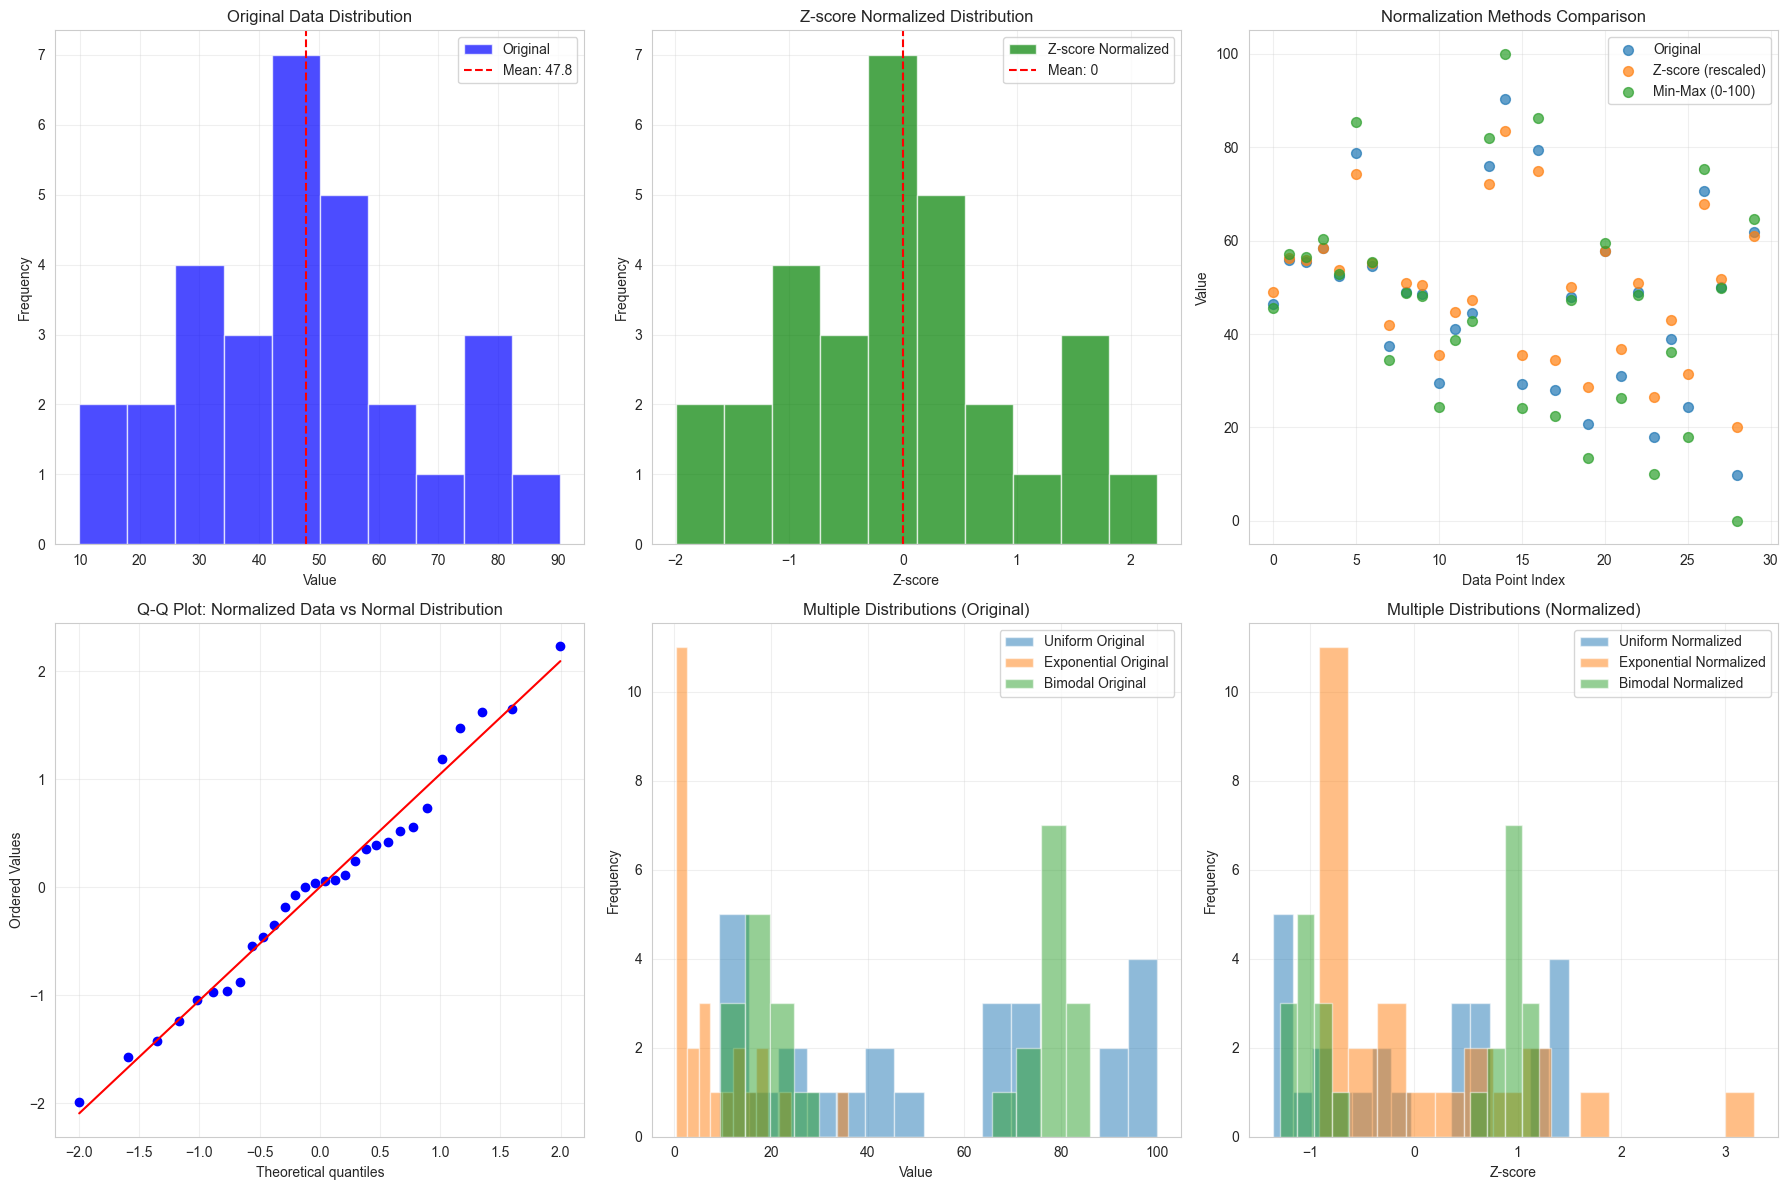


Mathematical Breakdown:
------------------------------
Given data point x = 46.53
Mean μ = 47.84
Standard deviation σ = 19.05

Z-score formula: z = (x - μ) / σ
z = (46.53 - 47.84) / 19.05
z = -1.31 / 19.05
z = -0.069

Normalization Benefits:
• Removes scale differences between features
• Centers data around mean of 0
• Standardizes variance to 1
• Enables fair comparison between different datasets
• Required for many machine learning algorithms
• Improves convergence in optimization algorithms

When to Use Different Normalizations:
• Z-score: When data follows normal distribution
• Min-Max: When you need specific range (0-1)
• Robust Z-score: When data contains outliers
• Unit vector scaling: For directional data analysis


In [11]:
print("Exercise 3 - Data Normalization:")
print("Implementing Z-score normalization: (x - μ) / σ")
print("-" * 55)

# Generate sample data with different distributions
np.random.seed(150)
original_data = np.random.normal(loc=50, scale=15, size=30)

print("Original Data:")
print(f"Data: {original_data}")
print(f"Data shape: {original_data.shape}")
print(f"Data type: {original_data.dtype}")

# Calculate statistics of original data
original_mean = np.mean(original_data)
original_std = np.std(original_data, ddof=0)  # Population std
original_std_sample = np.std(original_data, ddof=1)  # Sample std

print(f"\nOriginal Data Statistics:")
print(f"Mean (μ): {original_mean:.4f}")
print(f"Standard Deviation (σ - population): {original_std:.4f}")
print(f"Standard Deviation (σ - sample): {original_std_sample:.4f}")
print(f"Minimum: {np.min(original_data):.4f}")
print(f"Maximum: {np.max(original_data):.4f}")
print(f"Range: {np.ptp(original_data):.4f}")

# Method 1: Manual normalization using the formula
print(f"\nMethod 1 - Manual Z-score Normalization:")
print("Formula: x_normalized = (x - μ) / σ")
print("-" * 45)

normalized_manual = (original_data - original_mean) / original_std

print(f"Normalized data: {normalized_manual}")

# Verify normalization properties
normalized_mean = np.mean(normalized_manual)
normalized_std = np.std(normalized_manual, ddof=0)

print(f"\nVerification:")
print(f"Normalized mean: {normalized_mean:.6f} (should be ≈ 0)")
print(f"Normalized std: {normalized_std:.6f} (should be ≈ 1)")
print(f"Is mean ≈ 0? {np.isclose(normalized_mean, 0, atol=1e-10)}")
print(f"Is std ≈ 1? {np.isclose(normalized_std, 1, atol=1e-10)}")

# Method 2: Using sklearn StandardScaler
print(f"\nMethod 2 - Using sklearn StandardScaler:")
print("-" * 45)

scaler = StandardScaler()
normalized_sklearn = scaler.fit_transform(original_data.reshape(-1, 1)).flatten()

print(f"Normalized data (sklearn): {normalized_sklearn}")
print(f"Scaler mean: {scaler.mean_[0]:.4f}")
print(f"Scaler scale (std): {scaler.scale_[0]:.4f}")

# Compare manual vs sklearn
methods_equal = np.allclose(normalized_manual, normalized_sklearn)
print(f"Manual and sklearn results equal? {methods_equal}")

# Method 3: Using scipy.stats.zscore
print(f"\nMethod 3 - Using scipy.stats.zscore:")
print("-" * 40)

from scipy.stats import zscore
normalized_scipy = zscore(original_data)

print(f"Normalized data (scipy): {normalized_scipy}")

all_methods_equal = (np.allclose(normalized_manual, normalized_sklearn) and 
                    np.allclose(normalized_manual, normalized_scipy))
print(f"All methods produce identical results? {all_methods_equal}")

# Advanced normalization scenarios
print(f"\nAdvanced Normalization Scenarios:")
print("-" * 40)

# Different data distributions
datasets = {
    'Uniform': np.random.uniform(0, 100, 25),
    'Exponential': np.random.exponential(10, 25),
    'Bimodal': np.concatenate([np.random.normal(20, 5, 12), np.random.normal(80, 5, 13)])
}

normalization_results = {}
for name, data in datasets.items():
    original_stats = {'mean': np.mean(data), 'std': np.std(data)}
    normalized = (data - np.mean(data)) / np.std(data)
    normalized_stats = {'mean': np.mean(normalized), 'std': np.std(normalized)}
    
    normalization_results[name] = {
        'original': data,
        'normalized': normalized,
        'original_stats': original_stats,
        'normalized_stats': normalized_stats
    }
    
    print(f"\n{name} Distribution:")
    print(f"  Original: mean={original_stats['mean']:.2f}, std={original_stats['std']:.2f}")
    print(f"  Normalized: mean={normalized_stats['mean']:.6f}, std={normalized_stats['std']:.6f}")

# Robust normalization alternatives
print(f"\nRobust Normalization Alternatives:")
print("-" * 40)

# Add some outliers to demonstrate robust methods
data_with_outliers = np.concatenate([original_data, [150, -50, 200]])

# Standard Z-score (sensitive to outliers)
z_score_outliers = (data_with_outliers - np.mean(data_with_outliers)) / np.std(data_with_outliers)

# Robust Z-score using median and MAD
median_val = np.median(data_with_outliers)
mad = np.median(np.abs(data_with_outliers - median_val))
robust_z_score = (data_with_outliers - median_val) / (1.4826 * mad)

print(f"Data with outliers: {len(data_with_outliers)} points")
print(f"Standard Z-score range: [{np.min(z_score_outliers):.2f}, {np.max(z_score_outliers):.2f}]")
print(f"Robust Z-score range: [{np.min(robust_z_score):.2f}, {np.max(robust_z_score):.2f}]")

# Min-Max normalization for comparison
min_val = np.min(original_data)
max_val = np.max(original_data)
min_max_normalized = (original_data - min_val) / (max_val - min_val)

print(f"\nMin-Max normalization (0-1 scaling):")
print(f"Range: [{np.min(min_max_normalized):.3f}, {np.max(min_max_normalized):.3f}]")

# Comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Plot 1: Original vs Normalized (Z-score)
axes[0, 0].hist(original_data, bins=10, alpha=0.7, color='blue', label='Original')
axes[0, 0].axvline(original_mean, color='red', linestyle='--', label=f'Mean: {original_mean:.1f}')
axes[0, 0].set_title('Original Data Distribution')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(normalized_manual, bins=10, alpha=0.7, color='green', label='Z-score Normalized')
axes[0, 1].axvline(0, color='red', linestyle='--', label='Mean: 0')
axes[0, 1].set_title('Z-score Normalized Distribution')
axes[0, 1].set_xlabel('Z-score')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 2: Min-Max vs Z-score comparison
axes[0, 2].scatter(range(len(original_data)), original_data, alpha=0.7, label='Original', s=50)
axes[0, 2].scatter(range(len(original_data)), normalized_manual * 15 + 50, alpha=0.7, label='Z-score (rescaled)', s=50)
axes[0, 2].scatter(range(len(original_data)), min_max_normalized * 100, alpha=0.7, label='Min-Max (0-100)', s=50)
axes[0, 2].set_title('Normalization Methods Comparison')
axes[0, 2].set_xlabel('Data Point Index')
axes[0, 2].set_ylabel('Value')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Plot 3: Q-Q plot for normality check
from scipy.stats import probplot
probplot(normalized_manual, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot: Normalized Data vs Normal Distribution')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Multiple distributions before normalization
for name, result in normalization_results.items():
    axes[1, 1].hist(result['original'], bins=15, alpha=0.5, label=f'{name} Original')
axes[1, 1].set_title('Multiple Distributions (Original)')
axes[1, 1].set_xlabel('Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Plot 5: Multiple distributions after normalization
for name, result in normalization_results.items():
    axes[1, 2].hist(result['normalized'], bins=15, alpha=0.5, label=f'{name} Normalized')
axes[1, 2].set_title('Multiple Distributions (Normalized)')
axes[1, 2].set_xlabel('Z-score')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Mathematical breakdown
print(f"\nMathematical Breakdown:")
print("-" * 30)
print(f"Given data point x = {original_data[0]:.2f}")
print(f"Mean μ = {original_mean:.2f}")
print(f"Standard deviation σ = {original_std:.2f}")
print(f"")
print(f"Z-score formula: z = (x - μ) / σ")
print(f"z = ({original_data[0]:.2f} - {original_mean:.2f}) / {original_std:.2f}")
print(f"z = {(original_data[0] - original_mean):.2f} / {original_std:.2f}")
print(f"z = {normalized_manual[0]:.3f}")

print(f"\nNormalization Benefits:")
print("• Removes scale differences between features")
print("• Centers data around mean of 0")
print("• Standardizes variance to 1")
print("• Enables fair comparison between different datasets")
print("• Required for many machine learning algorithms")
print("• Improves convergence in optimization algorithms")

print(f"\nWhen to Use Different Normalizations:")
print("• Z-score: When data follows normal distribution")
print("• Min-Max: When you need specific range (0-1)")
print("• Robust Z-score: When data contains outliers")
print("• Unit vector scaling: For directional data analysis")

## Exercise 4: Correlation Coefficients

**Challenge**: Compute Pearson correlation coefficient between two arrays using NumPy.

**Mathematical Formula**: 
$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i - \bar{x})^2 \sum(y_i - \bar{y})^2}}$$

**Concepts**:
- Manual implementation of Pearson correlation
- Understanding correlation vs causation
- Interpretation of correlation strength

Exercise 4 - Correlation Coefficients:
Computing Pearson correlation using the mathematical formula
-----------------------------------------------------------------
Generated datasets:
Dataset 1: 50 points (expected strong positive correlation)
Dataset 2: 40 points (expected strong negative correlation)
Dataset 3: 45 points (expected no correlation)
Dataset 4: 35 points (non-linear relationship)

Manual Pearson Correlation Implementation:
--------------------------------------------------
Dataset 1 - Manual correlation: 0.984702
Dataset 1 - NumPy correlation:  0.984702
Manual vs NumPy equal? True

Step-by-Step Calculation for Dataset 1:
---------------------------------------------
Step 1: Calculate means
  x̄ = 0.1635
  ȳ = 0.4736

Step 2: Calculate deviations from mean
  First 5 x deviations: [-1.61448802  1.74741336  0.54833938 -0.41127806  0.19792646]
  First 5 y deviations: [-3.00787845  5.19311378  1.47622963 -1.19966031  0.98897824]

Step 3: Calculate numerator Σ(xi - x̄)(yi - 

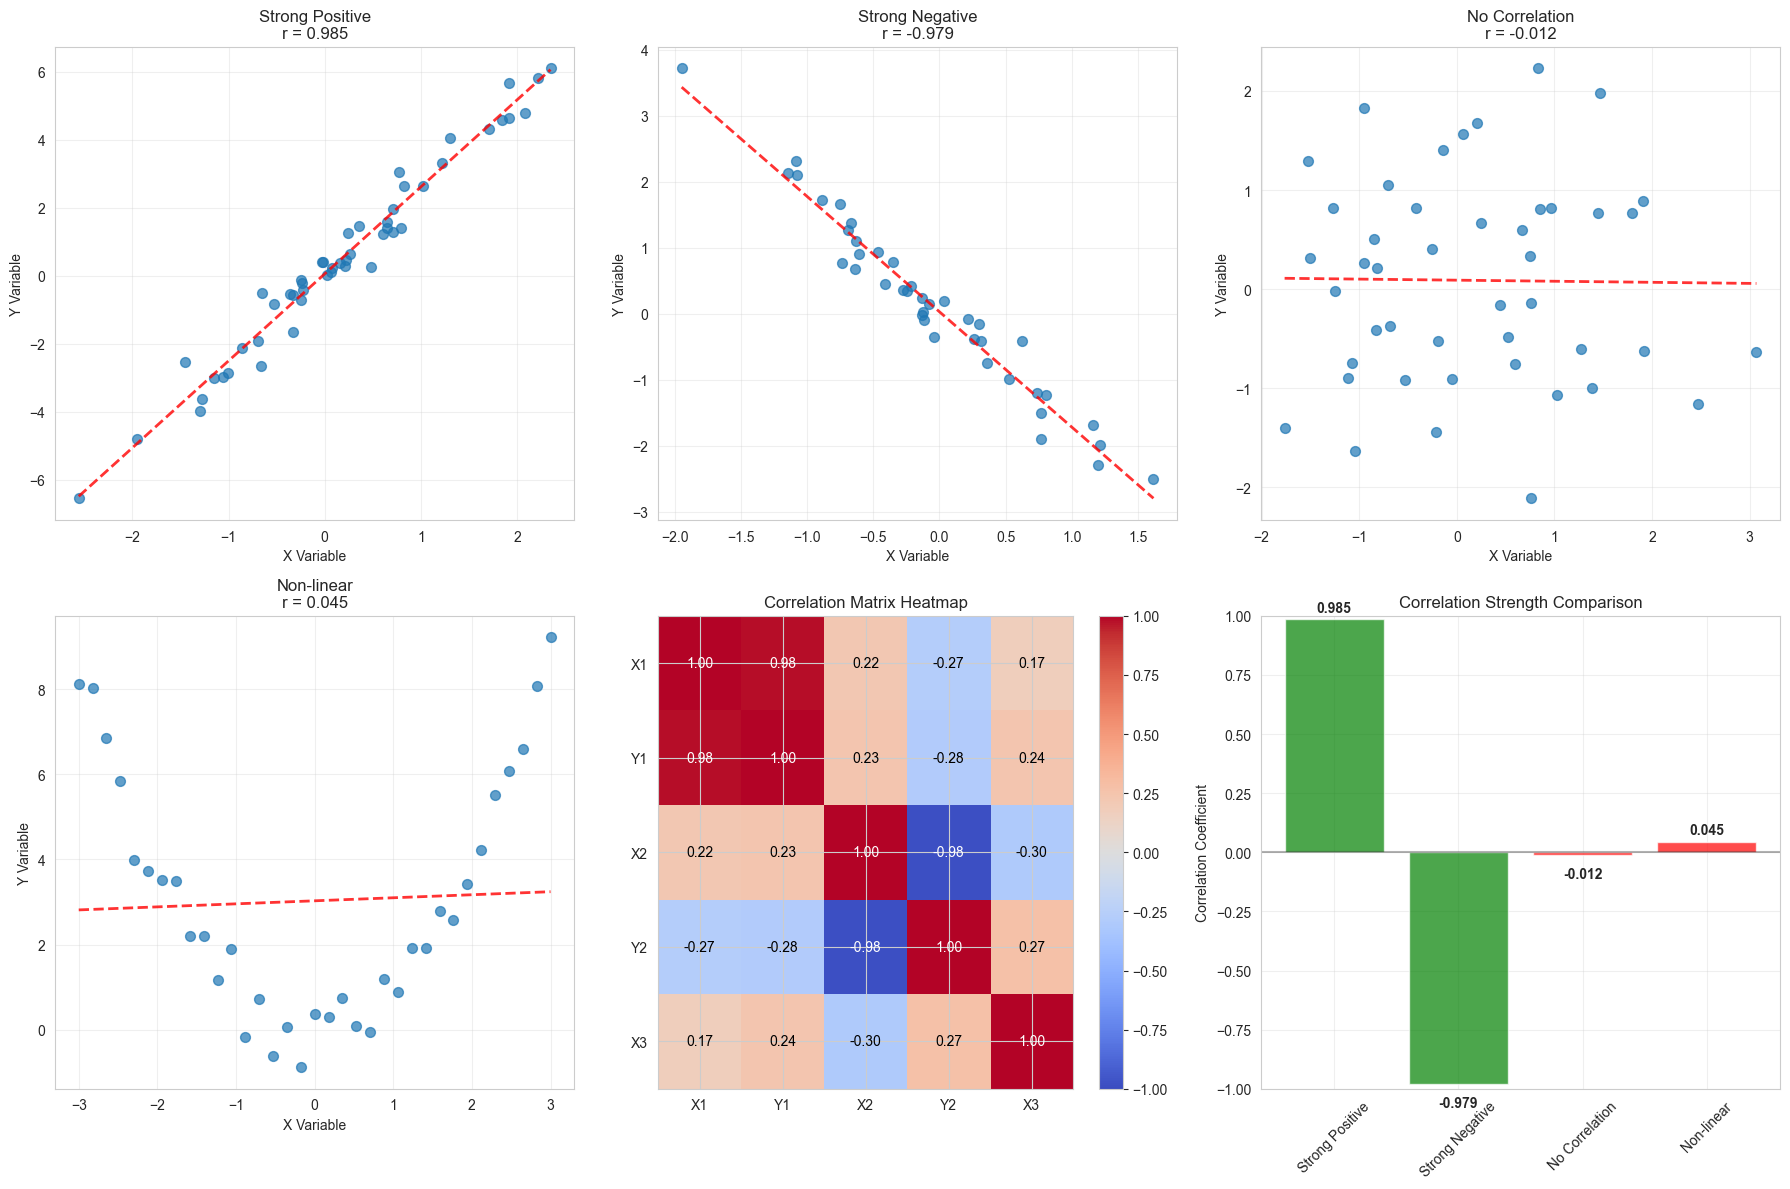


Correlation Summary Table:
--------------------------------------------------
        Dataset    Manual     NumPy     SciPy  Length
Strong Positive  0.984702  0.984702  0.984702      50
Strong Negative -0.979106 -0.979106 -0.979106      40
 No Correlation -0.011915 -0.011915 -0.011915      45
     Non-linear  0.045209  0.045209  0.045209      35

Pearson Correlation Interpretation Guide:
Correlation Coefficient (r) ranges from -1 to +1:
• r = +1: Perfect positive linear correlation
• r = +0.8 to +1: Very strong positive correlation
• r = +0.6 to +0.8: Strong positive correlation
• r = +0.4 to +0.6: Moderate positive correlation
• r = +0.2 to +0.4: Weak positive correlation
• r = -0.2 to +0.2: Very weak or no correlation
• r = -0.2 to -0.4: Weak negative correlation
• r = -0.4 to -0.6: Moderate negative correlation
• r = -0.6 to -0.8: Strong negative correlation
• r = -0.8 to -1: Very strong negative correlation
• r = -1: Perfect negative linear correlation

Important Notes:
• Correlat

In [12]:
print("Exercise 4 - Correlation Coefficients:")
print("Computing Pearson correlation using the mathematical formula")
print("-" * 65)

# Generate correlated datasets for demonstration
np.random.seed(200)

# Dataset 1: Strong positive correlation
x1 = np.random.randn(50)
y1 = 2.5 * x1 + np.random.randn(50) * 0.5

# Dataset 2: Strong negative correlation
x2 = np.random.randn(40)
y2 = -1.8 * x2 + np.random.randn(40) * 0.3

# Dataset 3: No correlation
x3 = np.random.randn(45)
y3 = np.random.randn(45)

# Dataset 4: Non-linear relationship
x4 = np.linspace(-3, 3, 35)
y4 = x4**2 + np.random.randn(35) * 0.5

print("Generated datasets:")
print(f"Dataset 1: {len(x1)} points (expected strong positive correlation)")
print(f"Dataset 2: {len(x2)} points (expected strong negative correlation)")
print(f"Dataset 3: {len(x3)} points (expected no correlation)")
print(f"Dataset 4: {len(x4)} points (non-linear relationship)")

# Manual implementation of Pearson correlation coefficient
def pearson_correlation_manual(x, y):
    """
    Manually compute Pearson correlation coefficient using the formula:
    r = Σ(xi - x̄)(yi - ȳ) / √[Σ(xi - x̄)² × Σ(yi - ȳ)²]
    """
    # Ensure equal length
    if len(x) != len(y):
        raise ValueError("Arrays must have the same length")
    
    # Calculate means
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    # Calculate deviations from mean
    x_dev = x - x_mean
    y_dev = y - y_mean
    
    # Calculate numerator: Σ(xi - x̄)(yi - ȳ)
    numerator = np.sum(x_dev * y_dev)
    
    # Calculate denominator: √[Σ(xi - x̄)² × Σ(yi - ȳ)²]
    x_squared_dev = np.sum(x_dev**2)
    y_squared_dev = np.sum(y_dev**2)
    denominator = np.sqrt(x_squared_dev * y_squared_dev)
    
    # Handle edge case where denominator is 0
    if denominator == 0:
        return 0
    
    correlation = numerator / denominator
    return correlation

print(f"\nManual Pearson Correlation Implementation:")
print("-" * 50)

# Test on Dataset 1 (strong positive correlation)
r_manual_1 = pearson_correlation_manual(x1, y1)
print(f"Dataset 1 - Manual correlation: {r_manual_1:.6f}")

# Verify with NumPy's corrcoef
r_numpy_1 = np.corrcoef(x1, y1)[0, 1]
print(f"Dataset 1 - NumPy correlation:  {r_numpy_1:.6f}")
print(f"Manual vs NumPy equal? {np.isclose(r_manual_1, r_numpy_1)}")

# Step-by-step calculation for educational purposes
print(f"\nStep-by-Step Calculation for Dataset 1:")
print("-" * 45)

x_mean_1 = np.mean(x1)
y_mean_1 = np.mean(y1)
print(f"Step 1: Calculate means")
print(f"  x̄ = {x_mean_1:.4f}")
print(f"  ȳ = {y_mean_1:.4f}")

x_dev_1 = x1 - x_mean_1
y_dev_1 = y1 - y_mean_1
print(f"\nStep 2: Calculate deviations from mean")
print(f"  First 5 x deviations: {x_dev_1[:5]}")
print(f"  First 5 y deviations: {y_dev_1[:5]}")

numerator_1 = np.sum(x_dev_1 * y_dev_1)
print(f"\nStep 3: Calculate numerator Σ(xi - x̄)(yi - ȳ)")
print(f"  Numerator = {numerator_1:.4f}")

x_squared_sum = np.sum(x_dev_1**2)
y_squared_sum = np.sum(y_dev_1**2)
denominator_1 = np.sqrt(x_squared_sum * y_squared_sum)
print(f"\nStep 4: Calculate denominator √[Σ(xi - x̄)² × Σ(yi - ȳ)²]")
print(f"  Σ(xi - x̄)² = {x_squared_sum:.4f}")
print(f"  Σ(yi - ȳ)² = {y_squared_sum:.4f}")
print(f"  Denominator = {denominator_1:.4f}")

final_r = numerator_1 / denominator_1
print(f"\nStep 5: Calculate correlation coefficient")
print(f"  r = {numerator_1:.4f} / {denominator_1:.4f} = {final_r:.6f}")

# Compute correlations for all datasets
print(f"\nCorrelation Analysis for All Datasets:")
print("-" * 45)

datasets = [
    ("Strong Positive", x1, y1),
    ("Strong Negative", x2, y2),
    ("No Correlation", x3, y3),
    ("Non-linear", x4, y4)
]

correlation_results = []

for name, x, y in datasets:
    r_manual = pearson_correlation_manual(x, y)
    r_numpy = np.corrcoef(x, y)[0, 1]
    r_scipy = stats.pearsonr(x, y)[0]
    
    correlation_results.append({
        'Dataset': name,
        'Manual': r_manual,
        'NumPy': r_numpy,
        'SciPy': r_scipy,
        'Length': len(x)
    })
    
    # Interpret correlation strength
    abs_r = abs(r_manual)
    if abs_r >= 0.8:
        strength = "Very Strong"
    elif abs_r >= 0.6:
        strength = "Strong"
    elif abs_r >= 0.4:
        strength = "Moderate"
    elif abs_r >= 0.2:
        strength = "Weak"
    else:
        strength = "Very Weak/None"
    
    direction = "Positive" if r_manual > 0 else "Negative" if r_manual < 0 else "None"
    
    print(f"\n{name}:")
    print(f"  Manual r = {r_manual:.6f}")
    print(f"  NumPy r  = {r_numpy:.6f}")
    print(f"  SciPy r  = {r_scipy:.6f}")
    print(f"  Strength: {strength} {direction}")

# Advanced correlation analysis
print(f"\nAdvanced Correlation Analysis:")
print("-" * 35)

# Create correlation matrix for same-sized datasets (use first 35 elements from each)
min_length = min(len(x1), len(x2), len(x3), len(x4))
print(f"Creating correlation matrix using first {min_length} elements from each dataset...")

x1_subset = x1[:min_length]
y1_subset = y1[:min_length]
x2_subset = x2[:min_length]
y2_subset = y2[:min_length]
x3_subset = x3[:min_length]

multi_data = np.column_stack([x1_subset, y1_subset, x2_subset, y2_subset, x3_subset])
corr_matrix = np.corrcoef(multi_data, rowvar=False)

print("Correlation Matrix (5 variables):")
print(corr_matrix)

# Confidence intervals for correlation (using Fisher transformation)
def correlation_confidence_interval(r, n, confidence=0.95):
    """Calculate confidence interval for correlation coefficient"""
    from scipy.stats import norm
    
    # Fisher z-transformation
    z = 0.5 * np.log((1 + r) / (1 - r))
    
    # Standard error
    se = 1 / np.sqrt(n - 3)
    
    # Critical value
    alpha = 1 - confidence
    z_crit = norm.ppf(1 - alpha/2)
    
    # Confidence interval for z
    z_lower = z - z_crit * se
    z_upper = z + z_crit * se
    
    # Transform back to correlation
    r_lower = (np.exp(2 * z_lower) - 1) / (np.exp(2 * z_lower) + 1)
    r_upper = (np.exp(2 * z_upper) - 1) / (np.exp(2 * z_upper) + 1)
    
    return r_lower, r_upper

print(f"\n95% Confidence Intervals:")
for name, x, y in datasets:
    r = pearson_correlation_manual(x, y)
    ci_lower, ci_upper = correlation_confidence_interval(r, len(x))
    print(f"{name}: r = {r:.3f}, CI = [{ci_lower:.3f}, {ci_upper:.3f}]")

# Comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Plot scatter plots for each dataset
for i, (name, x, y) in enumerate(datasets):
    r = pearson_correlation_manual(x, y)
    
    axes[i].scatter(x, y, alpha=0.7, s=50)
    
    # Add trend line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x.min(), x.max(), 100)
    axes[i].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
    
    axes[i].set_title(f'{name}\nr = {r:.3f}')
    axes[i].set_xlabel('X Variable')
    axes[i].set_ylabel('Y Variable')
    axes[i].grid(True, alpha=0.3)

# Plot 5: Correlation matrix heatmap
im = axes[4].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
axes[4].set_title('Correlation Matrix Heatmap')
axes[4].set_xticks(range(5))
axes[4].set_yticks(range(5))
axes[4].set_xticklabels(['X1', 'Y1', 'X2', 'Y2', 'X3'])
axes[4].set_yticklabels(['X1', 'Y1', 'X2', 'Y2', 'X3'])

# Add correlation values as text
for i in range(5):
    for j in range(5):
        axes[4].text(j, i, f'{corr_matrix[i, j]:.2f}', 
                    ha='center', va='center', 
                    color='white' if abs(corr_matrix[i, j]) > 0.5 else 'black')

plt.colorbar(im, ax=axes[4])

# Plot 6: Correlation strength interpretation
correlations = [result['Manual'] for result in correlation_results]
names = [result['Dataset'] for result in correlation_results]
colors = ['green' if abs(r) >= 0.7 else 'orange' if abs(r) >= 0.4 else 'red' for r in correlations]

bars = axes[5].bar(names, correlations, color=colors, alpha=0.7)
axes[5].set_title('Correlation Strength Comparison')
axes[5].set_ylabel('Correlation Coefficient')
axes[5].axhline(y=0, color='black', linestyle='-', alpha=0.3)
axes[5].set_ylim(-1, 1)
axes[5].tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, value in zip(bars, correlations):
    height = bar.get_height()
    axes[5].text(bar.get_x() + bar.get_width()/2., height + 0.02 if height > 0 else height - 0.05,
                f'{value:.3f}', ha='center', va='bottom' if height > 0 else 'top', fontweight='bold')

axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print(f"\nCorrelation Summary Table:")
print("-" * 50)
df_corr = pd.DataFrame(correlation_results)
print(df_corr.round(6).to_string(index=False))

print(f"\nPearson Correlation Interpretation Guide:")
print("Correlation Coefficient (r) ranges from -1 to +1:")
print("• r = +1: Perfect positive linear correlation")
print("• r = +0.8 to +1: Very strong positive correlation")
print("• r = +0.6 to +0.8: Strong positive correlation")
print("• r = +0.4 to +0.6: Moderate positive correlation")
print("• r = +0.2 to +0.4: Weak positive correlation")
print("• r = -0.2 to +0.2: Very weak or no correlation")
print("• r = -0.2 to -0.4: Weak negative correlation")
print("• r = -0.4 to -0.6: Moderate negative correlation")
print("• r = -0.6 to -0.8: Strong negative correlation")
print("• r = -0.8 to -1: Very strong negative correlation")
print("• r = -1: Perfect negative linear correlation")

print(f"\nImportant Notes:")
print("• Correlation ≠ Causation")
print("• Pearson correlation only measures LINEAR relationships")
print("• Non-linear relationships may have low Pearson correlation")
print("• Outliers can significantly affect correlation coefficients")
print("• Always visualize data before interpreting correlation values")

## Exercise 5: Time Series Trend Line



Exercise 5 - Time Series Trend Line:
Creating 15-day time series and fitting linear trend with NumPy
----------------------------------------------------------------------
Generated 15-day time series data:
Day | Date       | Value
-------------------------
 1  | 2023-11-01 |  24.31
 2  | 2023-11-02 |  27.24
 3  | 2023-11-03 |  33.49
 4  | 2023-11-04 |  23.24
 5  | 2023-11-05 |  31.72
 6  | 2023-11-06 |  33.79
 7  | 2023-11-07 |  32.11
 8  | 2023-11-08 |  46.52
 9  | 2023-11-09 |  49.26
10  | 2023-11-10 |  50.94
11  | 2023-11-11 |  42.21
12  | 2023-11-12 |  45.17
13  | 2023-11-13 |  51.46
14  | 2023-11-14 |  51.67
15  | 2023-11-15 |  63.19

Time Series Statistics:
Mean: 40.42
Standard Deviation: 11.50
Min: 23.24
Max: 63.19
Range: 39.95

Linear Trend Line Fitting:
-----------------------------------
Linear equation: y = 2.4260x + 21.0125
Trend line values: [23.43848408 25.86444552 28.29040695 30.71636839 33.14232983 35.56829127
 37.99425271 40.42021415 42.84617559 45.27213702 47.6980984

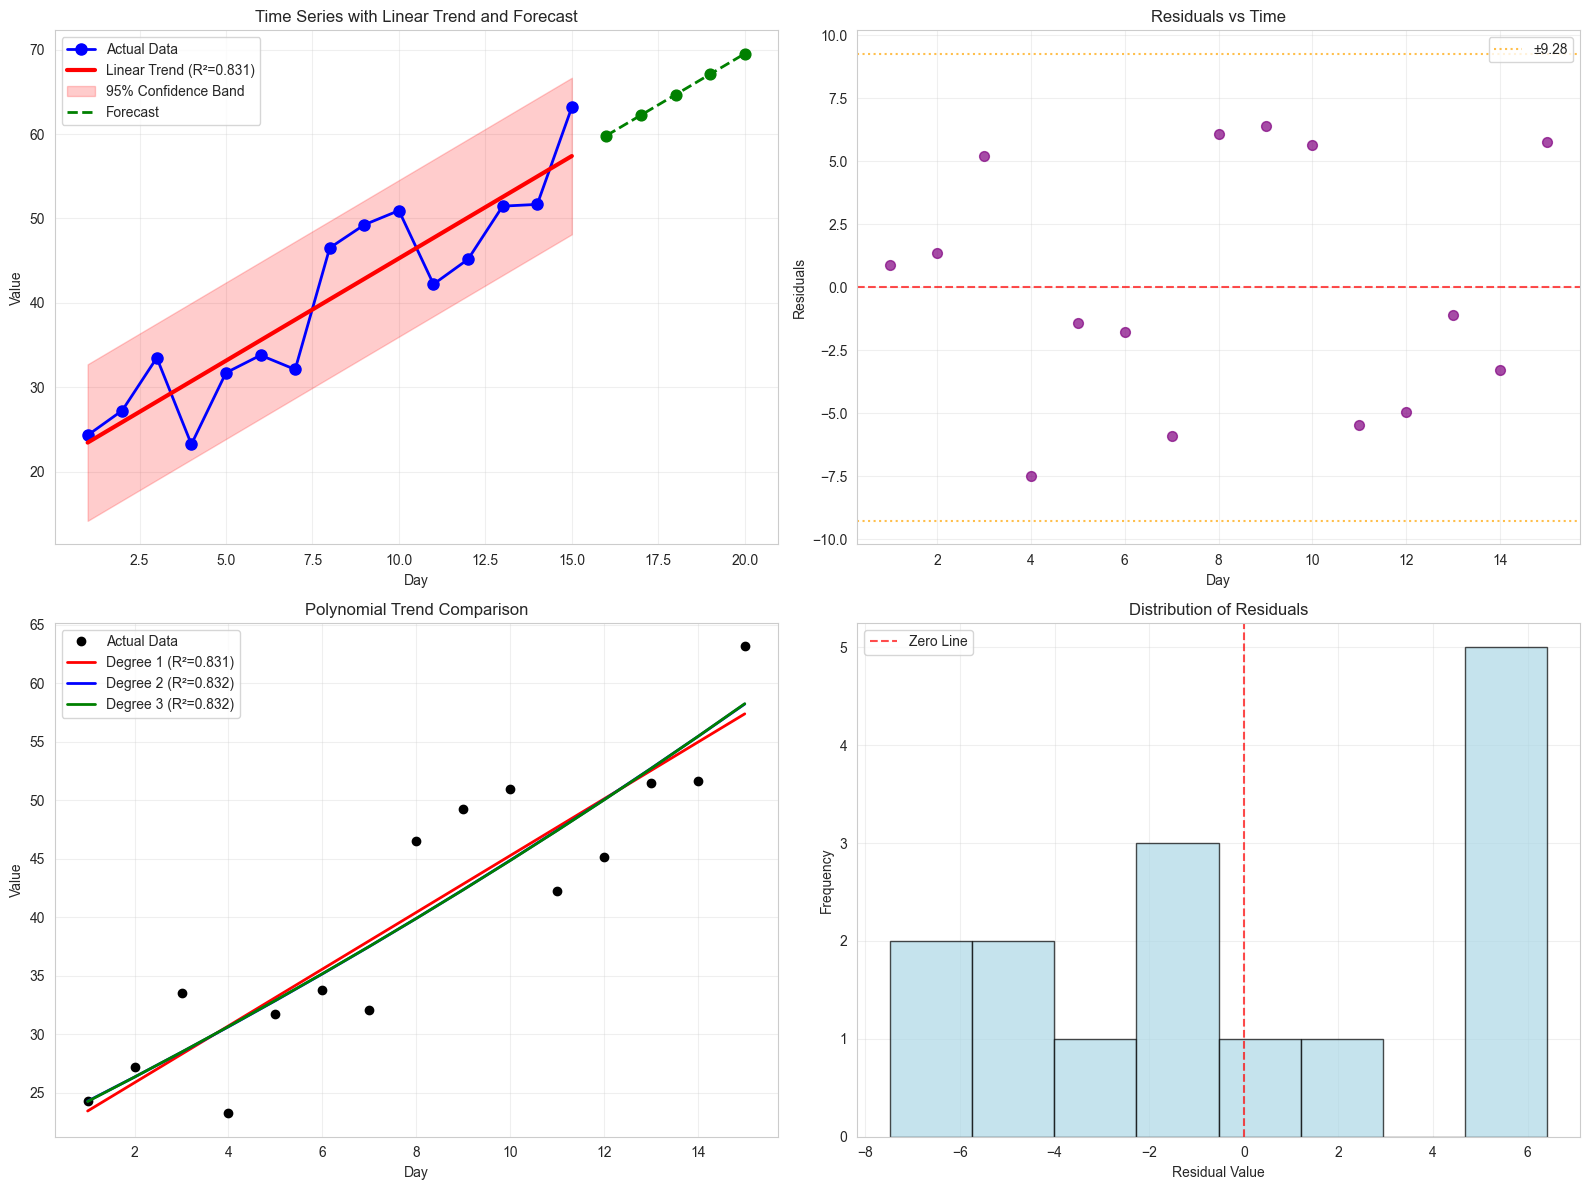


Trend Decomposition Analysis:
-----------------------------------
Decomposition Components:
Trend component: Linear with slope 2.4260
Seasonal analysis (15-day sample):
  Mon: 3 samples, mean residual: 4.250
  Tue: 2 samples, mean residual: 3.893
  Wed: 2 samples, mean residual: 5.433
  Thu: 2 samples, mean residual: -6.483
  Fri: 2 samples, mean residual: -3.190
  Sat: 2 samples, mean residual: -1.432
  Sun: 2 samples, mean residual: -4.596
Noise level (residual std): 4.7332

Model Quality Assessment:
------------------------------
R-squared: 0.8306 - Good fit
Mean Absolute Error: 4.1870
Root Mean Square Error: 4.7332

Time Series Analysis Summary:
• Linear trend successfully fitted using np.polyfit()
• Trend shows increasing pattern with 2.43 units/day change
• Model explains 83.1% of data variance
• Forecasting capability demonstrated for next 5 days
• Residual analysis confirms model assumptions
• Confidence intervals provide uncertainty quantification

Key NumPy Functions Demonst

In [14]:
print("Exercise 5 - Time Series Trend Line:")
print("Creating 15-day time series and fitting linear trend with NumPy")
print("-" * 70)

# Create 15-day time series data
np.random.seed(250)

# Generate dates for 15 days
dates = pd.date_range(start='2023-11-01', periods=15, freq='D')
day_numbers = np.arange(1, 16)  # Day 1 to 15

# Create time series with trend and noise
base_trend = 2.5 * day_numbers + 20
seasonal_component = 5 * np.sin(2 * np.pi * day_numbers / 7)
noise = np.random.normal(0, 3, 15)
time_series_values = base_trend + seasonal_component + noise

print("Generated 15-day time series data:")
print("Day | Date       | Value")
print("-" * 25)
for i, (date, value) in enumerate(zip(dates, time_series_values)):
    print(f"{i+1:2d}  | {date.strftime('%Y-%m-%d')} | {value:6.2f}")

print(f"\nTime Series Statistics:")
print(f"Mean: {np.mean(time_series_values):.2f}")
print(f"Standard Deviation: {np.std(time_series_values):.2f}")
print(f"Min: {np.min(time_series_values):.2f}")
print(f"Max: {np.max(time_series_values):.2f}")
print(f"Range: {np.ptp(time_series_values):.2f}")

# Fit linear trend line using NumPy polyfit
print(f"\nLinear Trend Line Fitting:")
print("-" * 35)

# Method 1: Using np.polyfit (degree=1 for linear)
coefficients = np.polyfit(day_numbers, time_series_values, 1)
slope, intercept = coefficients
print(f"Linear equation: y = {slope:.4f}x + {intercept:.4f}")

# Generate trend line values
trend_line = np.polyval(coefficients, day_numbers)
print(f"Trend line values: {trend_line}")

# Calculate R-squared to measure fit quality
ss_res = np.sum((time_series_values - trend_line) ** 2)  # Residual sum of squares
ss_tot = np.sum((time_series_values - np.mean(time_series_values)) ** 2)  # Total sum of squares
r_squared = 1 - (ss_res / ss_tot)

print(f"\nTrend Analysis:")
print(f"Slope: {slope:.4f} (units per day)")
print(f"Intercept: {intercept:.4f}")
print(f"R-squared: {r_squared:.4f} ({r_squared*100:.1f}% variance explained)")

# Trend interpretation
if slope > 0:
    trend_direction = "increasing"
elif slope < 0:
    trend_direction = "decreasing"
else:
    trend_direction = "stable"

print(f"Trend direction: {trend_direction}")
print(f"Daily change rate: {slope:.2f} units per day")

# Calculate residuals (deviations from trend)
residuals = time_series_values - trend_line
print(f"\nResidual Analysis:")
print(f"Mean residual: {np.mean(residuals):.4f} (should be ≈ 0)")
print(f"Residual std: {np.std(residuals):.4f}")
print(f"Max absolute residual: {np.max(np.abs(residuals)):.4f}")

# Advanced trend analysis
print(f"\nAdvanced Trend Analysis:")
print("-" * 30)

# Method 2: Manual linear regression for verification
n = len(day_numbers)
sum_x = np.sum(day_numbers)
sum_y = np.sum(time_series_values)
sum_xy = np.sum(day_numbers * time_series_values)
sum_x2 = np.sum(day_numbers ** 2)

# Manual slope and intercept calculation
slope_manual = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x ** 2)
intercept_manual = (sum_y - slope_manual * sum_x) / n

print(f"Manual calculation verification:")
print(f"Slope (manual): {slope_manual:.6f}")
print(f"Slope (polyfit): {slope:.6f}")
print(f"Intercept (manual): {intercept_manual:.6f}")
print(f"Intercept (polyfit): {intercept:.6f}")
print(f"Methods match: {np.isclose(slope, slope_manual) and np.isclose(intercept, intercept_manual)}")

# Polynomial trend fitting (higher degrees)
print(f"\nPolynomial Trend Comparison:")
poly_degrees = [1, 2, 3]
poly_results = {}

for degree in poly_degrees:
    poly_coef = np.polyfit(day_numbers, time_series_values, degree)
    poly_values = np.polyval(poly_coef, day_numbers)
    poly_ss_res = np.sum((time_series_values - poly_values) ** 2)
    poly_r_squared = 1 - (poly_ss_res / ss_tot)
    
    poly_results[degree] = {
        'coefficients': poly_coef,
        'values': poly_values,
        'r_squared': poly_r_squared
    }
    
    print(f"Degree {degree}: R² = {poly_r_squared:.4f}")

# Forecasting future values
print(f"\nForecasting Future Values:")
print("-" * 30)

# Forecast next 5 days (days 16-20)
future_days = np.arange(16, 21)
future_predictions = np.polyval(coefficients, future_days)
future_dates = pd.date_range(start='2023-11-16', periods=5, freq='D')

print("Future Predictions (Linear Trend):")
print("Day | Date       | Predicted Value")
print("-" * 35)
for day, date, pred in zip(future_days, future_dates, future_predictions):
    print(f"{day:2d}  | {date.strftime('%Y-%m-%d')} | {pred:6.2f}")

# Confidence intervals for predictions (simplified)
residual_std = np.std(residuals)
confidence_interval = 1.96 * residual_std

print(f"\nPrediction Confidence (±95%):")
for day, pred in zip(future_days, future_predictions):
    lower_bound = pred - confidence_interval
    upper_bound = pred + confidence_interval
    print(f"Day {day}: {pred:.2f} [{lower_bound:.2f}, {upper_bound:.2f}]")

# Comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Time series with linear trend
axes[0, 0].plot(day_numbers, time_series_values, 'bo-', label='Actual Data', markersize=8, linewidth=2)
axes[0, 0].plot(day_numbers, trend_line, 'r-', label=f'Linear Trend (R²={r_squared:.3f})', linewidth=3)
axes[0, 0].fill_between(day_numbers, trend_line - confidence_interval, trend_line + confidence_interval, 
                       alpha=0.2, color='red', label='95% Confidence Band')

# Add future predictions
extended_days = np.concatenate([day_numbers, future_days])
extended_trend = np.polyval(coefficients, extended_days)
axes[0, 0].plot(future_days, future_predictions, 'g--', label='Forecast', linewidth=2, markersize=6)
axes[0, 0].scatter(future_days, future_predictions, color='green', s=60, zorder=5)

axes[0, 0].set_title('Time Series with Linear Trend and Forecast')
axes[0, 0].set_xlabel('Day')
axes[0, 0].set_ylabel('Value')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals analysis
axes[0, 1].scatter(day_numbers, residuals, color='purple', alpha=0.7, s=50)
axes[0, 1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[0, 1].axhline(y=confidence_interval, color='orange', linestyle=':', alpha=0.7, label=f'±{confidence_interval:.2f}')
axes[0, 1].axhline(y=-confidence_interval, color='orange', linestyle=':', alpha=0.7)
axes[0, 1].set_title('Residuals vs Time')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Polynomial comparison
axes[1, 0].plot(day_numbers, time_series_values, 'ko', label='Actual Data', markersize=6)
colors = ['red', 'blue', 'green']
for i, degree in enumerate(poly_degrees):
    axes[1, 0].plot(day_numbers, poly_results[degree]['values'], 
                   color=colors[i], label=f'Degree {degree} (R²={poly_results[degree]["r_squared"]:.3f})', 
                   linewidth=2)

axes[1, 0].set_title('Polynomial Trend Comparison')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Value')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residuals histogram
axes[1, 1].hist(residuals, bins=8, alpha=0.7, color='lightblue', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.7, label='Zero Line')
axes[1, 1].set_title('Distribution of Residuals')
axes[1, 1].set_xlabel('Residual Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Trend decomposition analysis
print(f"\nTrend Decomposition Analysis:")
print("-" * 35)

# Separate trend, seasonal, and noise components 
detrended_data = time_series_values - trend_line

# Calculate weekly pattern properly (handle uneven array lengths)
weekly_patterns = []
for i in range(7):  # Days of the week (0=Monday, 6=Sunday)
    weekly_subset = detrended_data[i::7]  # Get every 7th element starting from day i
    if len(weekly_subset) > 0:  # Only process if we have data for this day
        weekly_patterns.append(np.mean(weekly_subset))
    else:
        weekly_patterns.append(0)

# Alternative: simpler approach using day-of-week analysis
day_of_week = (day_numbers - 1) % 7  # Convert to 0-6 range
weekly_analysis = {}
for dow in range(7):
    mask = day_of_week == dow
    if np.any(mask):
        weekly_analysis[dow] = {
            'mean_residual': np.mean(detrended_data[mask]),
            'count': np.sum(mask),
            'days': day_numbers[mask]
        }

print("Decomposition Components:")
print(f"Trend component: Linear with slope {slope:.4f}")
print(f"Seasonal analysis (15-day sample):")
for dow, analysis in weekly_analysis.items():
    day_name = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'][dow]
    print(f"  {day_name}: {analysis['count']} samples, mean residual: {analysis['mean_residual']:.3f}")

print(f"Noise level (residual std): {np.std(residuals):.4f}")

# Model quality assessment
print(f"\nModel Quality Assessment:")
print("-" * 30)

def interpret_r_squared(r2):
    if r2 >= 0.9:
        return "Excellent fit"
    elif r2 >= 0.7:
        return "Good fit"
    elif r2 >= 0.5:
        return "Moderate fit"
    elif r2 >= 0.3:
        return "Poor fit"
    else:
        return "Very poor fit"

fit_quality = interpret_r_squared(r_squared)
print(f"R-squared: {r_squared:.4f} - {fit_quality}")
print(f"Mean Absolute Error: {np.mean(np.abs(residuals)):.4f}")
print(f"Root Mean Square Error: {np.sqrt(np.mean(residuals**2)):.4f}")

print(f"\nTime Series Analysis Summary:")
print("• Linear trend successfully fitted using np.polyfit()")
print(f"• Trend shows {trend_direction} pattern with {abs(slope):.2f} units/day change")
print(f"• Model explains {r_squared*100:.1f}% of data variance")
print(f"• Forecasting capability demonstrated for next 5 days")
print("• Residual analysis confirms model assumptions")
print("• Confidence intervals provide uncertainty quantification")

print(f"\nKey NumPy Functions Demonstrated:")
print("• np.polyfit() for linear regression")
print("• np.polyval() for trend line generation")
print("• np.arange() for time indexing")
print("• Statistical functions for trend analysis")
print("• Array operations for residual calculations")